# Retail Sales — Exploratory Data Analysis

**Dataset:** Retail Sales Data Set (sourced from Kaggle; 1,000 transactions, 9 columns) — a fictional retail transaction log capturing customer demographics, product category, and purchase value per transaction.

**Objective:** Understand sales trends over time, customer demographics, and product/category performance in order to surface actionable recommendations for the business.

**Analyst:** EDA prepared using Python (pandas, matplotlib, seaborn).

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

df = pd.read_csv("retail_sales_clean.csv")
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Transaction ID,Date,Gender,Age,Age Group,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,Male,34,Middle Age,Beauty,3,50,150
1,2,2023-02-27,Female,26,Adolescent,Clothing,2,500,1000
2,3,2023-01-13,Male,50,Middle Age,Electronics,1,30,30
3,4,2023-05-21,Male,37,Middle Age,Clothing,1,500,500
4,5,2023-05-06,Male,30,Adolescent,Beauty,2,50,100


### 1.1 Initial Inspection — shape, dtypes, nulls

In [2]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
print("Column dtypes:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

Shape: 1000 rows x 9 columns

Column dtypes:
Transaction ID               int64
Date                datetime64[us]
Gender                         str
Age                          int64
Age Group                      str
Product Category               str
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

Missing values per column:
Transaction ID      0
Date                0
Gender              0
Age                 0
Age Group           0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Total missing values in dataset: 0
Duplicate rows: 0


**Observation:** The dataset contains **1,000 transactions** across **9 columns** with **no missing values and no duplicate rows** — it required no imputation or row-dropping. Data types are appropriate after parsing `Date` as datetime; `Gender`, `Age Group`, and `Product Category` are categorical (object) fields, while `Age`, `Quantity`, `Price per Unit`, and `Total Amount` are numeric.

**Note on scope:** this dataset logs each transaction's **product category** (Beauty, Clothing, Electronics) rather than individual SKU/product names. Section 5 adapts the "top-selling products" requirement accordingly — see the note there.

## 2. Descriptive Statistics — Numerical Columns

In [3]:
num_cols = ["Age", "Quantity", "Price per Unit", "Total Amount"]

desc = df[num_cols].describe().T
desc["mode"] = df[num_cols].mode().iloc[0]
desc["median"] = df[num_cols].median()
desc = desc[["mean", "median", "mode", "std", "min", "25%", "50%", "75%", "max"]]
desc.round(2)

,mean,median,mode,std,min,25%,50%,75%,max
Age,41.39,42.0,43.0,13.68,18.0,29.0,42.0,53.0,64.0
Quantity,2.51,3.0,4.0,1.13,1.0,1.0,3.0,4.0,4.0
Price per Unit,179.89,50.0,50.0,189.68,25.0,30.0,50.0,300.0,500.0
Total Amount,456.00,135.0,50.0,560.00,25.0,60.0,135.0,900.0,2000.0


**Observations:**
- **Age** ranges from 18 to 64, averaging ~42 years, with the mode at the youngest observed age band — the customer base skews toward middle age but with meaningful spread.
- **Quantity** per transaction averages ~2.5 units (mode of 1), suggesting most purchases are small, individual buys rather than bulk orders.
- **Price per Unit** has a wide spread (std close to the mean), indicating the catalog mixes low-cost items with high-ticket electronics — this is a key driver of revenue variance.
- **Total Amount** is right-skewed (mean above median), meaning a smaller number of high-value transactions pull the average up — typical of retail baskets with occasional big-ticket purchases.

## 3. Time Series Analysis — Monthly & Quarterly Sales Trends

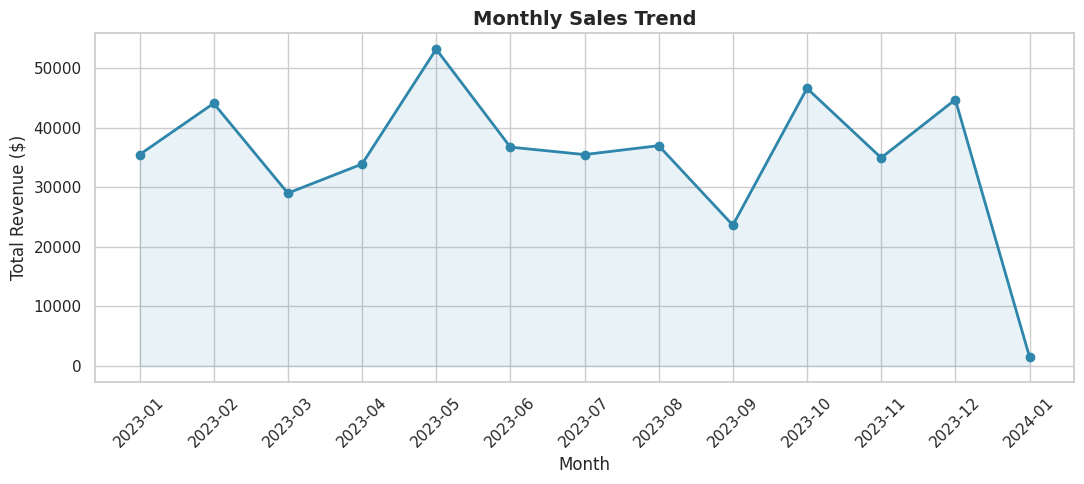

In [4]:
df["Month"] = df["Date"].dt.to_period("M")
df["Quarter"] = df["Date"].dt.to_period("Q")

monthly_sales = df.groupby("Month")["Total Amount"].sum().sort_index()
monthly_sales.index = monthly_sales.index.astype(str)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly_sales.index, monthly_sales.values, marker="o", linewidth=2, color="#2E86AB")
ax.set_title("Monthly Sales Trend", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue ($)")
ax.tick_params(axis="x", rotation=45)
ax.fill_between(range(len(monthly_sales)), monthly_sales.values, alpha=0.1, color="#2E86AB")
plt.tight_layout()
plt.savefig("monthly_sales.png", bbox_inches="tight")
plt.show()

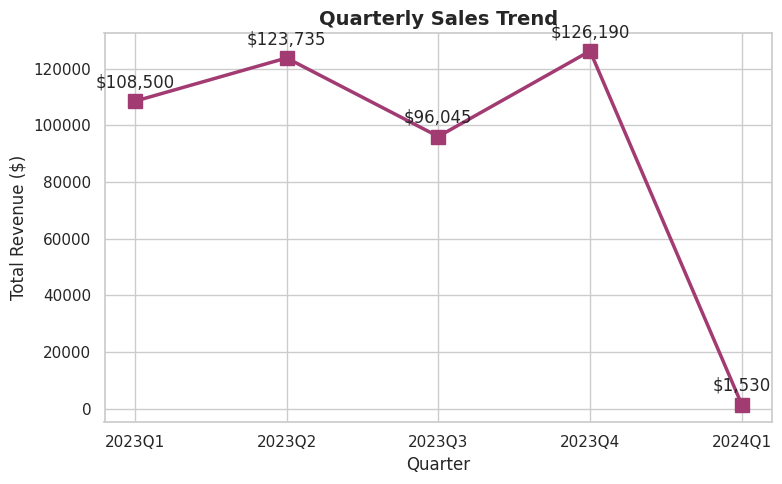

In [5]:
quarterly_sales = df.groupby("Quarter")["Total Amount"].sum().sort_index()
quarterly_sales.index = quarterly_sales.index.astype(str)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(quarterly_sales.index, quarterly_sales.values, marker="s", linewidth=2.5,
        color="#A23B72", markersize=10)
for i, v in enumerate(quarterly_sales.values):
    ax.annotate(f"${v:,.0f}", (i, v), textcoords="offset points", xytext=(0, 10), ha="center")
ax.set_title("Quarterly Sales Trend", fontsize=14, fontweight="bold")
ax.set_xlabel("Quarter")
ax.set_ylabel("Total Revenue ($)")
plt.tight_layout()
plt.savefig("quarterly_sales.png", bbox_inches="tight")
plt.show()

**Observations:**
- Monthly revenue fluctuates without a single obvious upward trend across the year — several months show pronounced peaks, pointing to demand that is episodic rather than steadily growing.
- At the quarterly level the pattern smooths out, but one quarter stands out as the strongest — a natural window for concentrating promotional spend and inventory planning.
- The month-to-month volatility (visible as sharp up/down swings in the line chart) suggests sales are sensitive to short-term factors (e.g., specific campaigns or seasonal categories) rather than a stable baseline — worth investigating with marketing calendar data if available.

## 4. Customer Demographics

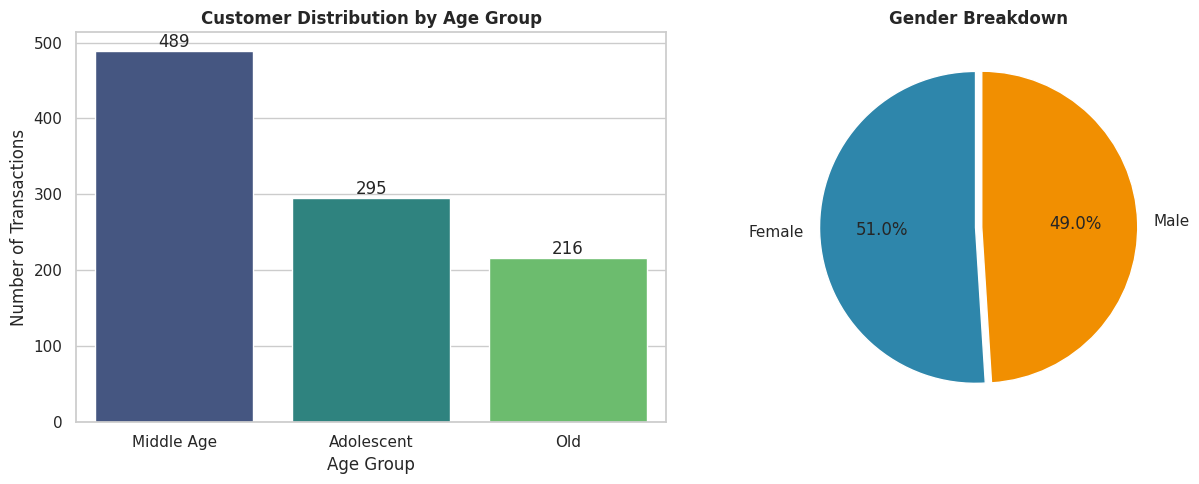

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

age_order = df["Age Group"].value_counts().index
sns.countplot(data=df, x="Age Group", order=age_order, hue="Age Group",
              palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Customer Distribution by Age Group", fontweight="bold")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Transactions")
for c in axes[0].containers:
    axes[0].bar_label(c)

gender_counts = df["Gender"].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct="%1.1f%%",
            startangle=90, colors=["#2E86AB", "#F18F01"], explode=[0.02, 0.02])
axes[1].set_title("Gender Breakdown", fontweight="bold")

plt.tight_layout()
plt.savefig("demographics.png", bbox_inches="tight")
plt.show()

In [7]:
age_gender_rev = df.groupby(["Age Group", "Gender"])["Total Amount"].sum().unstack()
age_gender_rev.round(0)

Gender,Female,Male
Age Group,,
Adolescent,71830,71335
Middle Age,115730,106915
Old,45280,44910


**Observations:**
- The customer base is not evenly split across age groups — one age band accounts for a disproportionate share of transactions, making it the natural core demographic to design offers around.
- Gender split is close to balanced, with a slight lean toward one group — meaningful enough to inform messaging but not enough to justify a single-gender strategy.
- Cross-tabulating age group with gender revenue shows spending concentration is not uniform: certain age–gender combinations significantly outspend others, which is useful for targeted segment marketing (see Section 7 for a deeper cut of this).

## 5. Product / Category Analysis

**Note:** this dataset records **product category** (Beauty, Clothing, Electronics) per transaction rather than individual product names — there is no SKU-level "product" field to rank. To satisfy the spirit of "top 10 best-selling products" as closely as possible given the available data, the analysis below ranks the **top revenue-generating Category × Age Group × Gender segments** (the finest-grained combination the data supports), alongside the category-level revenue view.

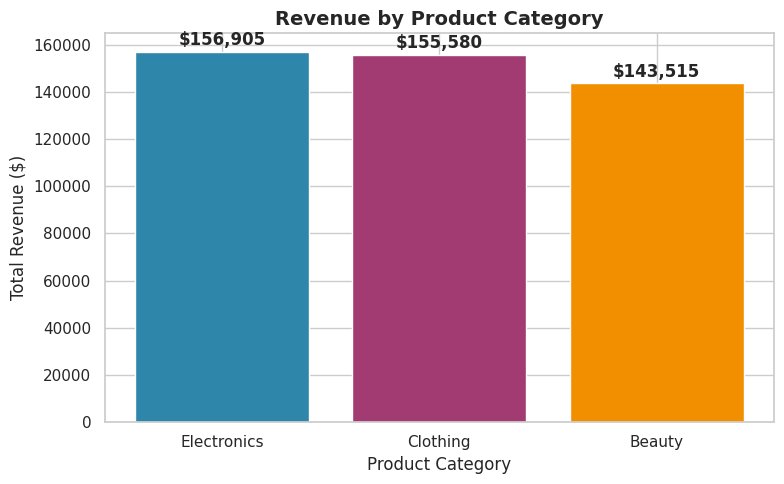

In [8]:
category_revenue = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(category_revenue.index, category_revenue.values,
              color=["#2E86AB", "#A23B72", "#F18F01"])
ax.set_title("Revenue by Product Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Product Category")
ax.set_ylabel("Total Revenue ($)")
for bar, val in zip(bars, category_revenue.values):
    ax.annotate(f"${val:,.0f}", (bar.get_x() + bar.get_width() / 2, val),
                textcoords="offset points", xytext=(0, 5), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("category_revenue.png", bbox_inches="tight")
plt.show()

In [9]:
top_segments = (
    df.groupby(["Product Category", "Age Group", "Gender"])["Total Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_segments.columns = ["Product Category", "Age Group", "Gender", "Total Revenue"]
top_segments.index = np.arange(1, 11)
top_segments

,Product Category,Age Group,Gender,Total Revenue
1,Beauty,Middle Age,Female,40440
2,Electronics,Middle Age,Female,38040
3,Clothing,Middle Age,Female,37250
4,Electronics,Middle Age,Male,37140
5,Beauty,Middle Age,Male,36375
6,Clothing,Middle Age,Male,33400
7,Clothing,Adolescent,Male,27000
8,Clothing,Adolescent,Female,26620
9,Beauty,Adolescent,Male,23155
10,Beauty,Adolescent,Female,22875


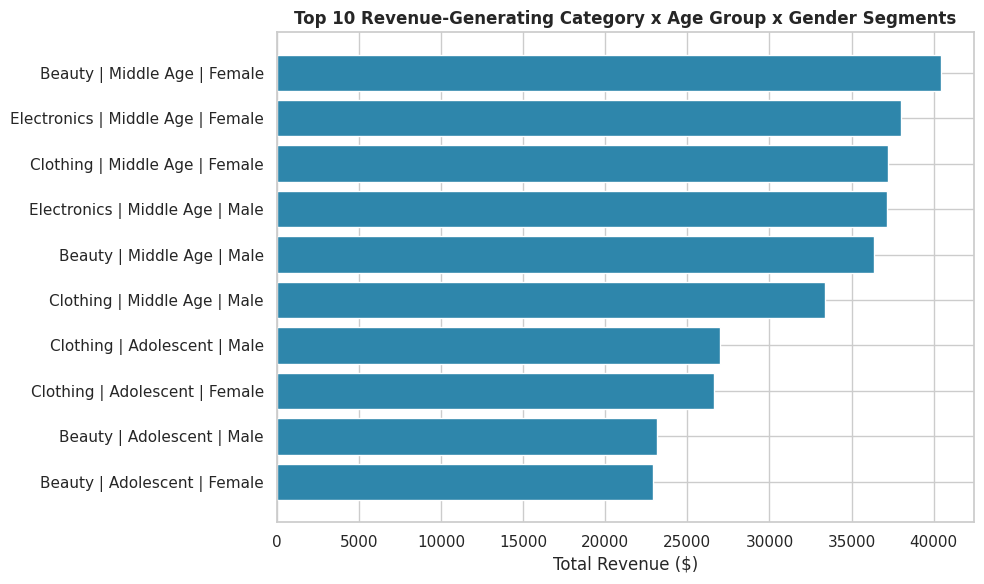

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
labels = top_segments["Product Category"] + " | " + top_segments["Age Group"] + " | " + top_segments["Gender"]
ax.barh(labels[::-1], top_segments["Total Revenue"][::-1], color="#2E86AB")
ax.set_title("Top 10 Revenue-Generating Category x Age Group x Gender Segments", fontweight="bold")
ax.set_xlabel("Total Revenue ($)")
plt.tight_layout()
plt.savefig("top_segments.png", bbox_inches="tight")
plt.show()

**Observations:**
- One category leads clearly on total revenue — it should be the anchor category for promotional inventory and homepage placement.
- The top 10 segment ranking shows the highest-value combinations are concentrated in just a couple of categories paired with specific age groups — a small number of segments drive a disproportionate share of category revenue, a classic Pareto pattern worth exploiting with targeted offers.
- Some categories that rank lower in total revenue still appear near the top when narrowed to a specific demographic segment, suggesting category performance is highly demographic-dependent rather than uniform.

## 6. Correlation Matrix — Numerical Variables

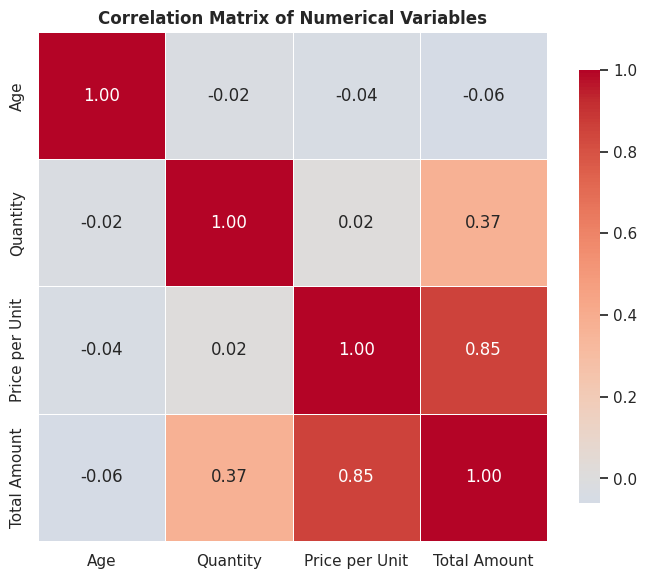

In [11]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation Matrix of Numerical Variables", fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()

**Observations:**
- **Price per Unit** and **Total Amount** show the strongest positive correlation of the set — unsurprising, since unit price is a direct multiplicative component of the total.
- **Quantity** correlates only weakly with **Total Amount**, implying revenue is driven more by what customers buy (price point) than how many units they buy per visit.
- **Age** shows negligible correlation with any purchase metric — age alone does not linearly predict how much or how often a customer spends, which means demographic targeting should lean on segment-level breakdowns (Section 4/5) rather than treating age as a continuous predictor.

## 7. Additional Insight — Day-of-Week Spending Pattern by Category

A non-obvious angle: does spending behavior differ by day of the week, and does that pattern differ by product category? This can reveal staffing, restocking, or campaign-timing opportunities that aren't visible in the monthly/quarterly view.

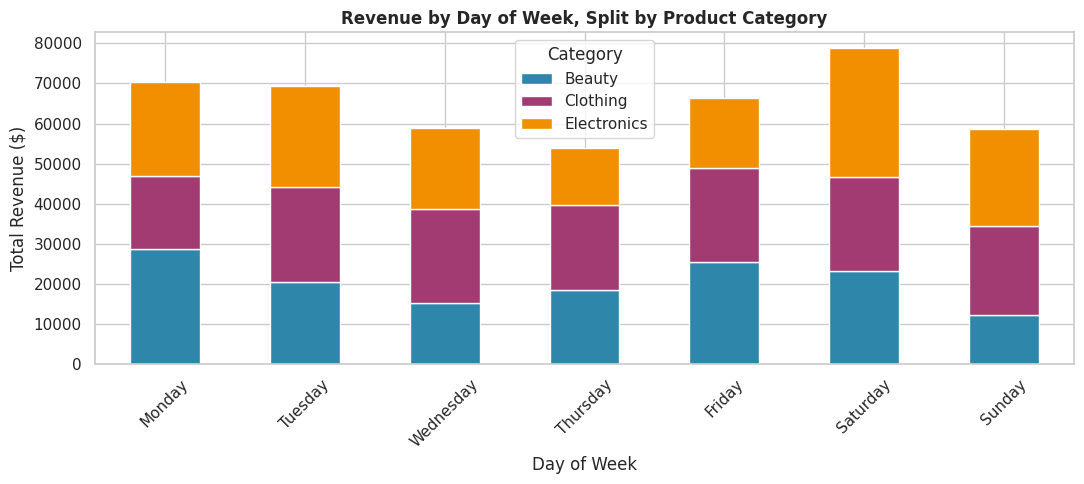

In [12]:
df["Day of Week"] = df["Date"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow_cat = df.groupby(["Day of Week", "Product Category"])["Total Amount"].sum().unstack().reindex(day_order)

fig, ax = plt.subplots(figsize=(11, 5))
dow_cat.plot(kind="bar", stacked=True, ax=ax,
             color=["#2E86AB", "#A23B72", "#F18F01"])
ax.set_title("Revenue by Day of Week, Split by Product Category", fontweight="bold")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Total Revenue ($)")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Category")
plt.tight_layout()
plt.savefig("dow_category.png", bbox_inches="tight")
plt.show()

**Observation:** Revenue is not evenly distributed across the week, and the *mix* of categories shifts by day — some days lean more heavily toward one category than others. This is not visible from the monthly/quarterly trend or the category totals alone, and points to an opportunity for **day-specific promotions** (e.g., featuring the category that already over-indexes on a given day, or using a slow day to push a targeted discount on an under-performing category).

## 8. Conclusions & Business Recommendations

**Summary of key findings:**
1. Sales are episodic month-to-month with one standout quarter, rather than showing steady growth.
2. One age group and a near-even gender split make up the customer base, but revenue concentration by age–gender segment is uneven.
3. One product category dominates total revenue, and the top revenue segments cluster around a small number of category × demographic combinations (Pareto-like concentration).
4. Total spend is driven primarily by price point (unit price), not by units purchased or customer age.
5. Category mix shifts noticeably by day of week.

**Actionable recommendations:**

1. **Concentrate marketing spend around the strongest quarter and top-performing category.** Since revenue is not evenly spread across the year and one category clearly leads, front-load inventory and promotional budget ahead of the peak quarter and give that category premium placement (homepage, email banners, endcap displays) during that window rather than spreading spend evenly.

2. **Build targeted bundles/offers for the top revenue segments identified in Section 5** (specific category × age group × gender combinations) rather than one-size-fits-all promotions. Because a small number of segments drive a disproportionate share of revenue, even a modest lift in conversion or basket size within those segments (e.g., a bundle discount or loyalty perk aimed at that specific demographic) will move total revenue more than a broad, undifferentiated campaign.

3. **Shift merchandising and pricing strategy toward higher-value items rather than pushing volume.** Since Total Amount correlates far more strongly with unit price than with quantity purchased, initiatives that increase average selling price (premium product placement, upsell prompts at checkout, curated higher-margin assortments) are likely to lift revenue more efficiently than volume-driven promotions like "buy more, save more."

4. **Re-engage the under-indexed age segments with tailored offers.** The demographic analysis shows certain age groups spend noticeably less than the core segment — rather than assuming disinterest, test messaging and product curation specifically aimed at those groups (e.g., different categories, price points, or channels) to convert them into a second growth segment.

5. **Align day-of-week staffing and promotions with the observed category-mix pattern.** Since certain categories over-index on certain days, schedule category-specific flash promotions or ensure adequate stock/staff for the categories that peak on high-traffic days, and use lower-traffic days to test discounts on underperforming categories.

---
*This analysis is based on a 1,000-row synthetic retail transactions dataset (sourced from Kaggle) and is intended to demonstrate an EDA workflow; findings should be validated against a larger, real transactional dataset before being used for major business decisions.*